In [115]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR



from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

import seaborn as sns
import pandas as pd


In [78]:
model = Ridge(alpha=1.0)

In [79]:
housing_data = pd.read_csv('house_price.csv')
housing_data.head()

print("=" * 60)
print(housing_data.info())
print("=" * 60)  


housing_data_model = housing_data.drop(columns=["property_id", "sale_date"])
 
# Target variable
TARGET = "house_price_inr"
 
# Feature columns
FEATURES = [col for col in housing_data_model.columns if col != TARGET]
 
print(f"\nTarget Variable : {TARGET}")
print(f"\nFeature Variables ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  • {f}")
 
X = housing_data_model[FEATURES]
y = housing_data_model[TARGET]
 
print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB
None

Target Variable : house_price_inr

Feature Variables (9):
  • area_sqft
  • bedrooms
  • bathrooms
  • location_score
  • property_age
  • distance_city_km
  • near_

In [80]:
x_train, x_test, train_target, test_target = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
SCALE_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "property_age",
    "distance_city_km",
    "crime_rate_index",
]

BINARY_FEATURES = ["near_school", "near_metro"]

scaler = StandardScaler()

train_features_scaled = x_train.copy()
test_features_scaled = x_test.copy()
train_features_scaled[SCALE_FEATURES] = scaler.fit_transform(x_train[SCALE_FEATURES])
test_features_scaled[SCALE_FEATURES] = scaler.transform(x_test[SCALE_FEATURES])

scale_summary = pd.DataFrame({
    "Feature" : SCALE_FEATURES,
    "Mean"    : scaler.mean_.round(4),
    "Std Dev" : scaler.scale_.round(4),
})

print(scale_summary.to_string(index=False))
 
print("\nSample of train_features_scaled (first 5 rows):")
print(train_features_scaled.head().to_string())
 
print("\nSample of test_features_scaled (first 5 rows):")
print(test_features_scaled.head().to_string())


         Feature      Mean  Std Dev
       area_sqft 1721.1503 584.2640
        bedrooms    3.4365   1.3572
       bathrooms    2.9207   1.1381
  location_score    6.5095   1.7401
    property_age   22.5470  12.3358
distance_city_km   13.0970   6.5523
crime_rate_index    4.2367   2.0524

Sample of X_train_scaled (first 5 rows):
      area_sqft  bedrooms  bathrooms  location_score  property_age  distance_city_km  near_school  near_metro  crime_rate_index
246    1.285121  1.888790   2.705537       -0.350289      0.442044         -0.289519            0           1          1.512038
862   -1.376348 -1.795235  -1.687601        1.086406      0.279914         -0.961041            1           1          0.103930
734   -0.036200  0.415180  -0.808973        0.626663     -0.936061         -1.846229            0           0          0.201377
505    0.119552 -1.058430  -0.808973        1.316277     -0.936061         -1.327326            1           0          0.157526
1647  -0.992959 -1.058430   0.

In [82]:
ridge_model_v2_model = Ridge(alpha=1.0)

# Train Model
ridge_model_v2_model.fit(train_features_scaled, train_target)

# Prediction
y_pred_ridge_model_v2 = ridge_model_v2_model.predict(test_features_scaled)

# Evaluation
ridge_model_v2_mse = mean_squared_error(test_target, y_pred_ridge_model_v2)
ridge_model_v2_rmse = np.sqrt(ridge_model_v2_mse)
ridge_model_v2_r2 = r2_score(test_target, y_pred_ridge_model_v2)

print("Ridge Regression Results ✅")
print("MSE :", ridge_model_v2_mse)
print("RMSE:", ridge_model_v2_rmse)
print("R2 Score:", ridge_model_v2_r2)


Ridge Regression Results ✅
MSE : 6545413082053.682
RMSE: 2558400.4928966225
R2 Score: 0.9187260281740323


In [83]:
# Lasso Model
lasso_model_v2_model = Lasso(alpha=1.0)

# Train Model
lasso_model_v2_model.fit(train_features_scaled, train_target)

# Prediction
y_pred_lasso_model_v2 = lasso_model_v2_model.predict(test_features_scaled)

# Evaluation
lasso_model_v2_mse = mean_squared_error(test_target, y_pred_lasso_model_v2)
lasso_model_v2_rmse = np.sqrt(lasso_model_v2_mse)
lasso_model_v2_r2 = r2_score(test_target, y_pred_lasso_model_v2)

print("Lasso Regression Results ✅")
print("MSE :", lasso_model_v2_mse)
print("RMSE:", lasso_model_v2_rmse)
print("R2 Score:", lasso_model_v2_r2)

Lasso Regression Results ✅
MSE : 6543996594589.265
RMSE: 2558123.6472440623
R2 Score: 0.9187436166074637


In [84]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_model_v2_cv = RidgeCV(alphas=alphas, cv=5)

ridge_model_v2_cv.fit(train_features_scaled, train_target)

print("Best Alpha for Ridge:", ridge_model_v2_cv.alpha_)

Best Alpha for Ridge: 1.0


In [85]:

lasso_model_v2_cv = LassoCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5,
    max_iter=10000
)

lasso_model_v2_cv.fit(train_features_scaled, train_target)

print("Best Alpha for Lasso:", lasso_model_v2_cv.alpha_)

Best Alpha for Lasso: 100.0


In [86]:

comparison = {
    "Model": ["Ridge", "Lasso"],
    
    "MSE": [
        mean_squared_error(test_target, y_pred_ridge_model_v2),
        mean_squared_error(test_target, y_pred_lasso_model_v2)
    ],
    
    "MAE": [
        mean_absolute_error(test_target, y_pred_ridge_model_v2),
        mean_absolute_error(test_target, y_pred_lasso_model_v2)
    ],
    
    "R2 Score": [
        r2_score(test_target, y_pred_ridge_model_v2),
        r2_score(test_target, y_pred_lasso_model_v2)
    ]
}

comparison_housing_data = pd.DataFrame(comparison)

print(comparison_housing_data)

   Model           MSE           MAE  R2 Score
0  Ridge  6.545413e+12  1.959198e+06  0.918726
1  Lasso  6.543997e+12  1.959378e+06  0.918744


In [87]:
coef_housing_data = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": ridge_model_v2_model.coef_,
    "Lasso Coefficient": lasso_model_v2_model.coef_
})

print(coef_housing_data)

            Feature  Ridge Coefficient  Lasso Coefficient
0         area_sqft       6.937545e+06       6.944896e+06
1          bedrooms       2.973645e+05       2.912014e+05
2         bathrooms       2.853276e+05       2.854317e+05
3    location_score       3.676863e+06       3.678968e+06
4      property_age      -6.513035e+05      -6.514824e+05
5  distance_city_km      -3.017064e+04      -2.879956e+04
6       near_school       3.406534e+04       3.396696e+04
7        near_metro       1.164625e+05       1.167605e+05
8  crime_rate_index      -1.354734e+05      -1.354010e+05


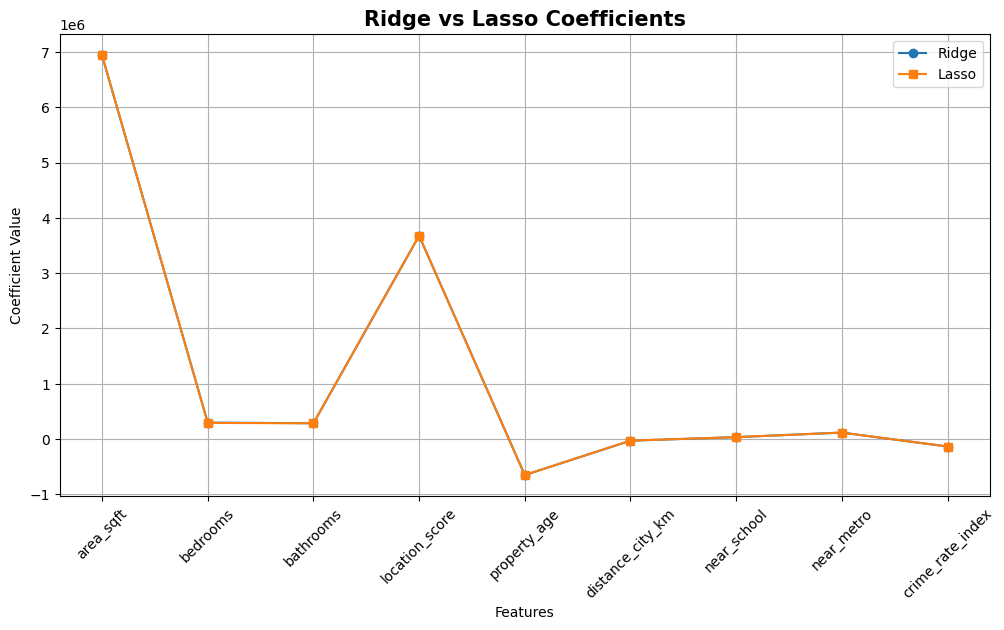

In [88]:
plt.figure(figsize=(12,6))

plt.plot(
    X.columns,
    ridge_model_v2_model.coef_,
    marker='o',
    label='Ridge'
)

plt.plot(
    X.columns,
    lasso_model_v2_model.coef_,
    marker='s',
    label='Lasso'
)

plt.xticks(rotation=45)

plt.title(
    "Ridge vs Lasso Coefficients",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.legend()
plt.grid(True)

plt.show()

In [89]:
ridge_model_v2 = Ridge(alpha=1.0)
lasso_model_v2 = Lasso(alpha=1.0)

ridge_model_v2.fit(train_features_scaled, train_target)
lasso_model_v2.fit(train_features_scaled, train_target)

ridge_model_v2_pred = ridge_model_v2.predict(test_features_scaled)
lasso_model_v2_pred = lasso_model_v2.predict(test_features_scaled)

In [90]:
ridge_model_v2_rmse = np.sqrt(
    mean_squared_error(test_target, ridge_model_v2_pred)
)

lasso_model_v2_rmse = np.sqrt(
    mean_squared_error(test_target, lasso_model_v2_pred)
)

print("Ridge RMSE:", ridge_model_v2_rmse)
print("Lasso RMSE:", lasso_model_v2_rmse)

Ridge RMSE: 2558400.4928966225
Lasso RMSE: 2558123.6472440623


In [91]:
alphas = np.logspace(-2, 5, 100)

ridge_model_v2_scores = []
lasso_model_v2_scores = []

for a in alphas:

    ridge_model_v2_model = Ridge(alpha=a)

    ridge_model_v2_cv = cross_val_score(
        ridge_model_v2_model,
        train_features_scaled,
        train_target,
        scoring='neg_mean_squared_error',
        cv=5
    )

    ridge_model_v2_scores.append(
        np.sqrt(-ridge_model_v2_cv.mean())
    )

    lasso_model_v2_model = Lasso(
        alpha=a,
        max_iter=10000
    )

    lasso_model_v2_cv = cross_val_score(
        lasso_model_v2_model,
        train_features_scaled,
        train_target,
        scoring='neg_mean_squared_error',
        cv=5
    )

    lasso_model_v2_scores.append(
        np.sqrt(-lasso_model_v2_cv.mean())
    )

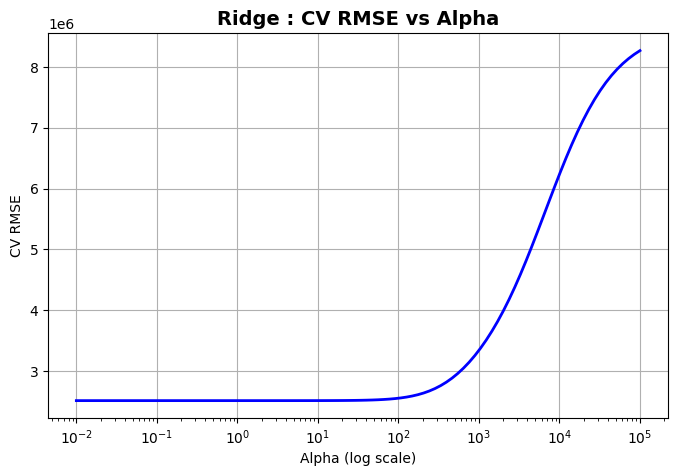

In [92]:
plt.figure(figsize=(8,5))

plt.plot(
    alphas,
    ridge_model_v2_scores,
    color='blue',
    linewidth=2
)

plt.xscale('log')

plt.title(
    "Ridge : CV RMSE vs Alpha",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Alpha (log scale)")
plt.ylabel("CV RMSE")

plt.grid(True)

plt.show()

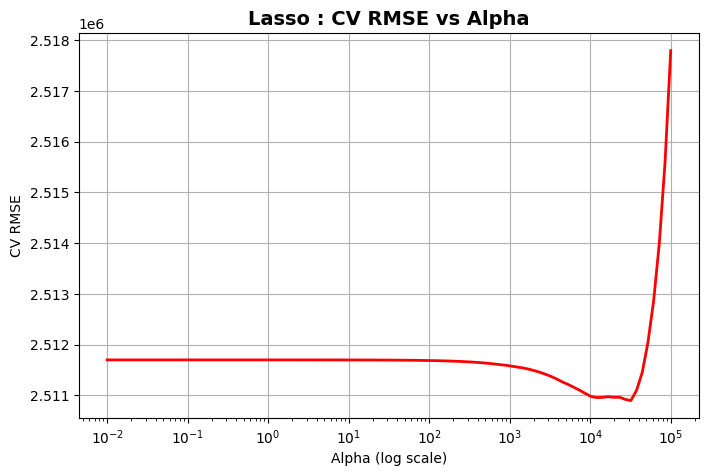

In [93]:
plt.figure(figsize=(8,5))

plt.plot(
    alphas,
    lasso_model_v2_scores,
    color='red',
    linewidth=2
)

plt.xscale('log')

plt.title(
    "Lasso : CV RMSE vs Alpha",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Alpha (log scale)")
plt.ylabel("CV RMSE")

plt.grid(True)

plt.show()

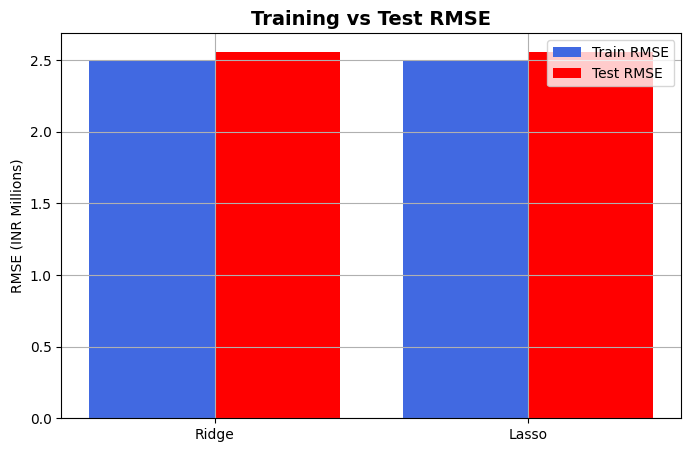

In [94]:
train_rmse = [
    np.sqrt(mean_squared_error(
        train_target,
        ridge_model_v2.predict(train_features_scaled)
    )) / 1e6,

    np.sqrt(mean_squared_error(
        train_target,
        lasso_model_v2.predict(train_features_scaled)
    )) / 1e6
]

test_rmse = [
    ridge_model_v2_rmse / 1e6,
    lasso_model_v2_rmse / 1e6
]

labels = ['Ridge', 'Lasso']

x = np.arange(len(labels))

plt.figure(figsize=(8,5))

plt.bar(
    x - 0.2,
    train_rmse,
    width=0.4,
    label='Train RMSE',
    color='royalblue'
)

plt.bar(
    x + 0.2,
    test_rmse,
    width=0.4,
    label='Test RMSE',
    color='red'
)

plt.xticks(x, labels)

plt.ylabel("RMSE (INR Millions)")

plt.title(
    "Training vs Test RMSE",
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True)

plt.show()

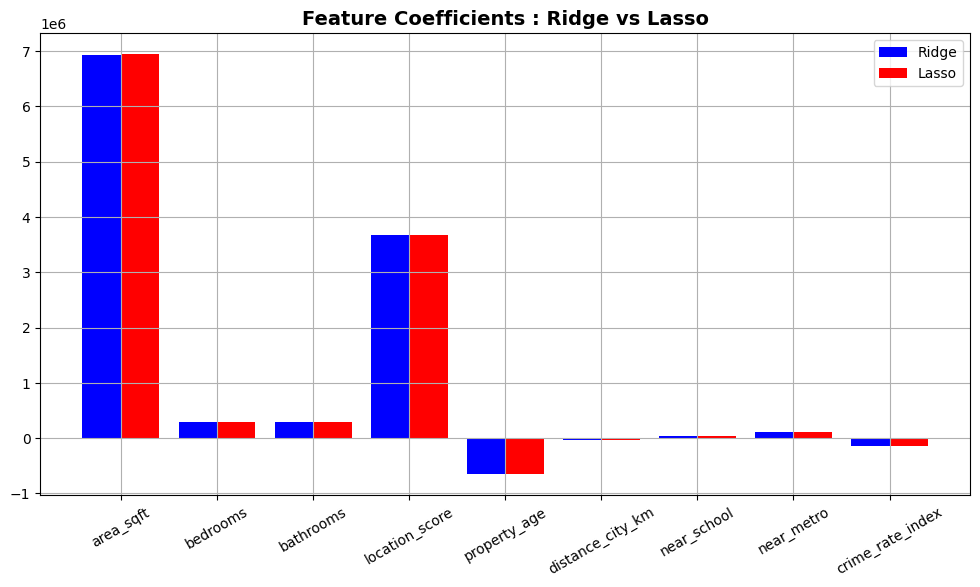

In [95]:
features = X.columns

plt.figure(figsize=(12,6))

x = np.arange(len(features))

plt.bar(
    x - 0.2,
    ridge_model_v2.coef_,
    width=0.4,
    label='Ridge',
    color='blue'
)

plt.bar(
    x + 0.2,
    lasso_model_v2.coef_,
    width=0.4,
    label='Lasso',
    color='red'
)

plt.xticks(
    x,
    features,
    rotation=30
)

plt.title(
    "Feature Coefficients : Ridge vs Lasso",
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True)

plt.show()

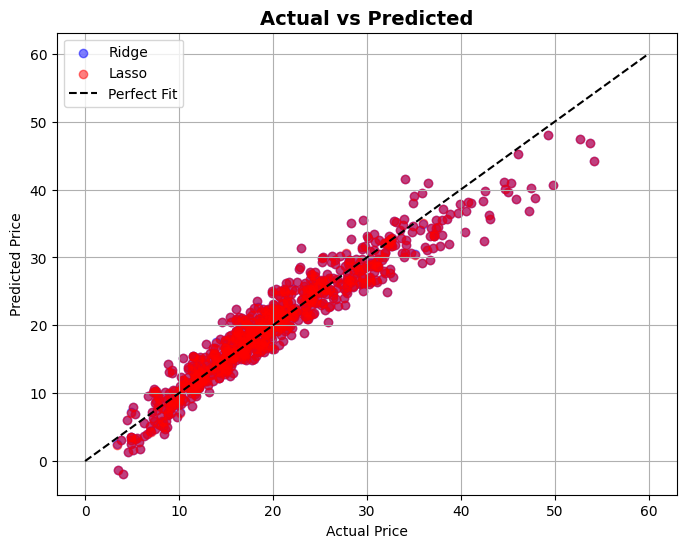

In [96]:
plt.figure(figsize=(8,6))

plt.scatter(
    test_target/1e6,
    ridge_model_v2_pred/1e6,
    color='blue',
    alpha=0.5,
    label='Ridge'
)

plt.scatter(
    test_target/1e6,
    lasso_model_v2_pred/1e6,
    color='red',
    alpha=0.5,
    label='Lasso'
)

plt.plot(
    [0, 60],
    [0, 60],
    color='black',
    linestyle='--',
    label='Perfect Fit'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted",
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True)

plt.show()

In [97]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    model,
    train_features_scaled,
    train_target,
    scoring='neg_mean_squared_error',
    cv=kfold
)

kfold_rmse = np.sqrt(-kfold_scores)

print("K-Fold RMSE Scores:\n")
print(kfold_rmse)

print("\nAverage RMSE:", kfold_rmse.mean())

K-Fold RMSE Scores:

[2513142.59701402 2671069.95061076 2467261.9566194  2415070.27906848
 2491795.52977818]

Average RMSE: 2511668.062618169


In [98]:
y_binned = pd.qcut(
    train_target,
    q=5,
    labels=False
)

In [99]:
strat_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

strat_scores = cross_val_score(
    model,
    train_features_scaled,
    train_target,
    scoring='neg_mean_squared_error',
    cv=strat_kfold.split(
        train_features_scaled,
        y_binned
    )
)

strat_rmse = np.sqrt(-strat_scores)

print("Stratified K-Fold RMSE:\n")
print(strat_rmse)

print("\nAverage RMSE:", strat_rmse.mean())

Stratified K-Fold RMSE:

[2558550.79169603 2459465.49638252 2442936.39779914 2443696.17561191
 2638887.30760811]

Average RMSE: 2508707.233819543


In [100]:
loo = LeaveOneOut()

loo_scores = cross_val_score(
    model,
    train_features_scaled[:100],
    train_target[:100],
    scoring='neg_mean_squared_error',
    cv=loo
)

loo_rmse = np.sqrt(-loo_scores)

print("LOOCV Average RMSE:")
print(loo_rmse.mean())

LOOCV Average RMSE:
1885177.9008015934


In [101]:
tscv = TimeSeriesSplit(
    n_splits=5
)

ts_scores = cross_val_score(
    model,
    train_features_scaled,
    train_target,
    scoring='neg_mean_squared_error',
    cv=tscv
)

ts_rmse = np.sqrt(-ts_scores)

print("Time Series Split RMSE:\n")
print(ts_rmse)

print("\nAverage RMSE:", ts_rmse.mean())

Time Series Split RMSE:

[2699644.95671166 2599118.31924503 2403044.83846682 2557094.49014088
 2425107.98256332]

Average RMSE: 2536802.1174255414


In [102]:
cv_results = pd.DataFrame({

    "Method": [
        "K-Fold",
        "Stratified K-Fold",
        "LOOCV",
        "Time Series Split"
    ],

    "Average RMSE": [

        kfold_rmse.mean(),

        strat_rmse.mean(),

        loo_rmse.mean(),

        ts_rmse.mean()
    ]
})

print(cv_results)

              Method  Average RMSE
0             K-Fold  2.511668e+06
1  Stratified K-Fold  2.508707e+06
2              LOOCV  1.885178e+06
3  Time Series Split  2.536802e+06


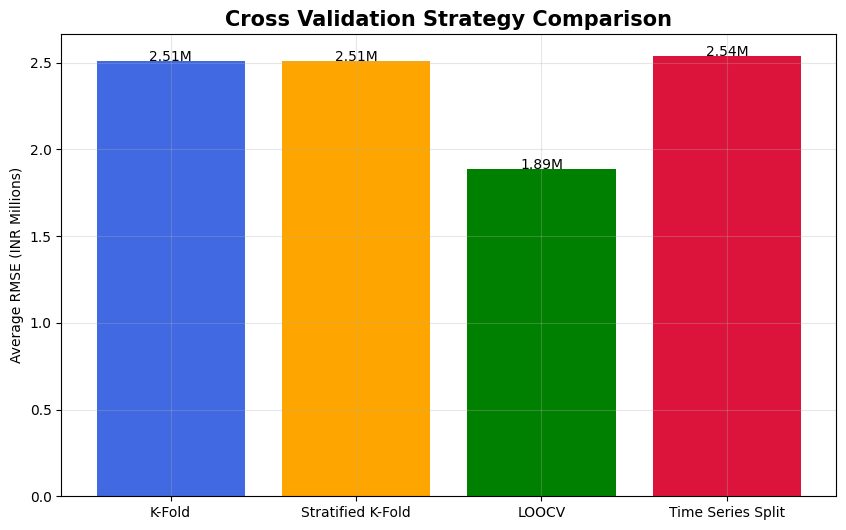

In [103]:

plt.figure(figsize=(10,6))

bars = plt.bar(
    cv_results["Method"],
    cv_results["Average RMSE"] / 1e6,
    color=[
        'royalblue',
        'orange',
        'green',
        'crimson'
    ]
)

plt.title(
    "Cross Validation Strategy Comparison",
    fontsize=15,
    fontweight='bold'
)

plt.ylabel("Average RMSE (INR Millions)")

plt.grid(True, alpha=0.3)

# Add values on top
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}M",
        ha='center',
        fontsize=10
    )

plt.show()

In [ ]:
# Keep only numeric columns
X = housing_data.select_dtypes(
    include=['int64', 'float64']
)

# Remove target
X = X.drop("house_price_inr", axis=1)

# Target
y = housing_data["house_price_inr"]

print(X.head())

   property_id  area_sqft  bedrooms  bathrooms  location_score  property_age  \
0       200001       2181         6          4             8.1            21   
1       200002       2383         5          4             5.3            28   
2       200003       1047         3          3             5.9             7   
3       200004       1753         4          3             7.0            27   
4       200005       1728         4          4            10.0            32   

   distance_city_km  near_school  near_metro  crime_rate_index  
0               3.8            0           0              4.84  
1              10.9            1           1              2.89  
2              27.5            0           1              4.04  
3              12.1            0           0              3.28  
4               1.4            0           1              3.84  


In [105]:
# Keep only numeric columns
X = housing_data.select_dtypes(
    include=['int64', 'float64']
)

# Remove target
X = X.drop("house_price_inr", axis=1)

# Target
y = housing_data["house_price_inr"]

print(X.head())

   property_id  area_sqft  bedrooms  bathrooms  location_score  property_age  \
0       200001       2181         6          4             8.1            21   
1       200002       2383         5          4             5.3            28   
2       200003       1047         3          3             5.9             7   
3       200004       1753         4          3             7.0            27   
4       200005       1728         4          4            10.0            32   

   distance_city_km  near_school  near_metro  crime_rate_index  
0               3.8            0           0              4.84  
1              10.9            1           1              2.89  
2              27.5            0           1              4.04  
3              12.1            0           0              3.28  
4               1.4            0           1              3.84  


In [106]:
train_features, test_features, train_target, test_target = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [107]:
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

dt_model.fit(train_features, train_target)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


In [110]:
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Train
dt_model.fit(train_features, train_target)

# Prediction
dt_pred = dt_model.predict(test_features)

# Evaluation
dt_rmse = mean_squared_error(
    test_target,
    dt_pred
) ** 0.5

dt_r2 = r2_score(
    test_target,
    dt_pred
)

print("Decision Tree RMSE :", round(dt_rmse,2))
print("Decision Tree R2   :", round(dt_r2,4))

Decision Tree RMSE : 3063631.25
Decision Tree R2   : 0.8835


In [109]:
# Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

# Train
rf_model.fit(train_features, train_target)

# Prediction
rf_pred = rf_model.predict(test_features)

# Evaluation
rf_rmse = mean_squared_error(
    test_target,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    test_target,
    rf_pred
)

print("Random Forest RMSE :", round(rf_rmse,2))
print("Random Forest R2   :", round(rf_r2,4))

Random Forest RMSE : 2434958.59
Random Forest R2   : 0.9264


In [111]:
models = ['Decision Tree', 'Random Forest']

rmse_values = [
    dt_rmse/1000000,
    rf_rmse/1000000
]

r2_values = [
    dt_r2,
    rf_r2
]

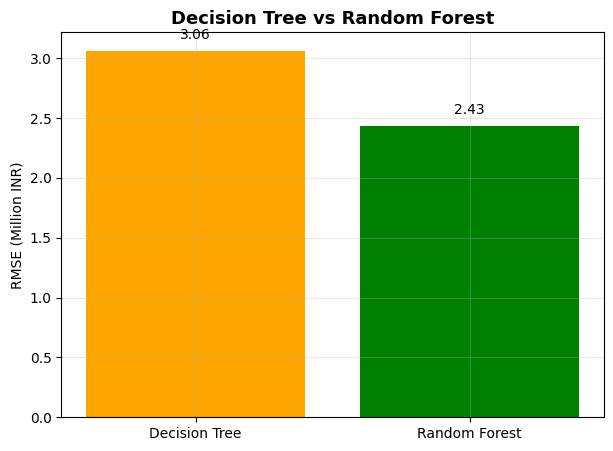

In [112]:

plt.figure(figsize=(7,5))

plt.bar(
    models,
    rmse_values,
    color=['orange','green']
)

plt.ylabel("RMSE (Million INR)")

plt.title(
    "Decision Tree vs Random Forest",
    fontsize=13,
    fontweight='bold'
)

for i,v in enumerate(rmse_values):
    plt.text(i, v+0.1, round(v,2),
             ha='center')

plt.grid(alpha=0.3)

plt.show()

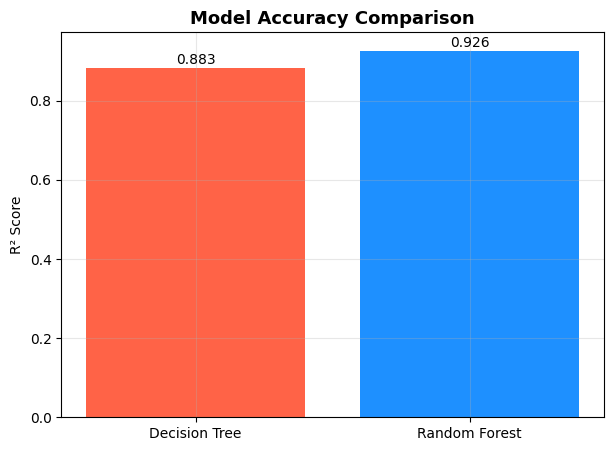

In [113]:
plt.figure(figsize=(7,5))

plt.bar(
    models,
    r2_values,
    color=['tomato','dodgerblue']
)

plt.ylabel("R² Score")

plt.title(
    "Model Accuracy Comparison",
    fontsize=13,
    fontweight='bold'
)

for i,v in enumerate(r2_values):
    plt.text(i, v+0.01, round(v,3),
             ha='center')

plt.grid(alpha=0.3)

plt.show()

In [114]:
print("Decision Tree works well but may overfit.")

print(
    "Random Forest gives better generalization "
    "because it combines multiple trees."
)

Decision Tree works well but may overfit.
Random Forest gives better generalization because it combines multiple trees.


In [116]:
# Linear SVR Model
svr_linear = SVR(
    kernel='linear',
    C=100,
    epsilon=0.1
)

# Train
svr_linear.fit(train_features, train_target)

# Prediction
linear_pred = svr_linear.predict(test_features)

print("Linear SVR Completed ✅")

Linear SVR Completed ✅


In [117]:
svr_rbf = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.1
)

# Train
svr_rbf.fit(train_features, train_target)

# Prediction
rbf_pred = svr_rbf.predict(test_features)

print("RBF SVR Completed ✅")

RBF SVR Completed ✅


In [118]:
def check_metrics(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    print("MSE  :", round(mse,2))
    print("MAE  :", round(mae,2))
    print("RMSE :", round(rmse,2))
    print("R2 Score :", round(r2,4))

In [119]:
print("Linear SVR Results\n")

check_metrics(
    test_target,
    linear_pred
)

Linear SVR Results

MSE  : 14551428546076.57
MAE  : 2852164.71
RMSE : 3814633.47
R2 Score : 0.8193


In [120]:
print("RBF SVR Results\n")

check_metrics(
    test_target,
    rbf_pred
)

RBF SVR Results

MSE  : 80774283876400.31
MAE  : 6994139.17
RMSE : 8987451.47
R2 Score : -0.003


In [121]:
linear_rmse = np.sqrt(
    mean_squared_error(test_target, linear_pred)
)

rbf_rmse = np.sqrt(
    mean_squared_error(test_target, rbf_pred)
)

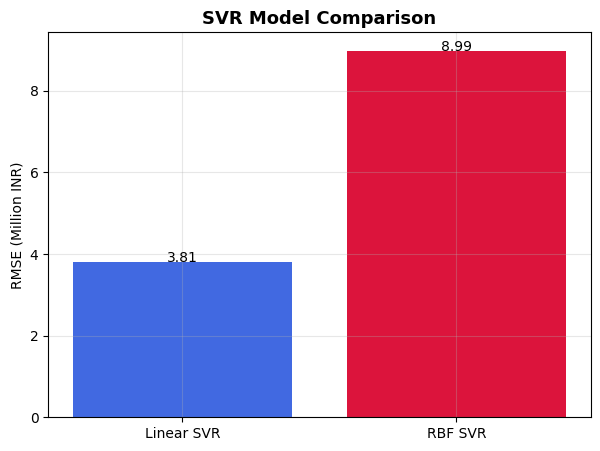

In [122]:
models = ['Linear SVR', 'RBF SVR']

rmse_values = [
    linear_rmse/1000000,
    rbf_rmse/1000000
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    rmse_values,
    color=['royalblue','crimson']
)

plt.ylabel("RMSE (Million INR)")

plt.title(
    "SVR Model Comparison",
    fontsize=13,
    fontweight='bold'
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center'
    )

plt.grid(alpha=0.3)

plt.show()

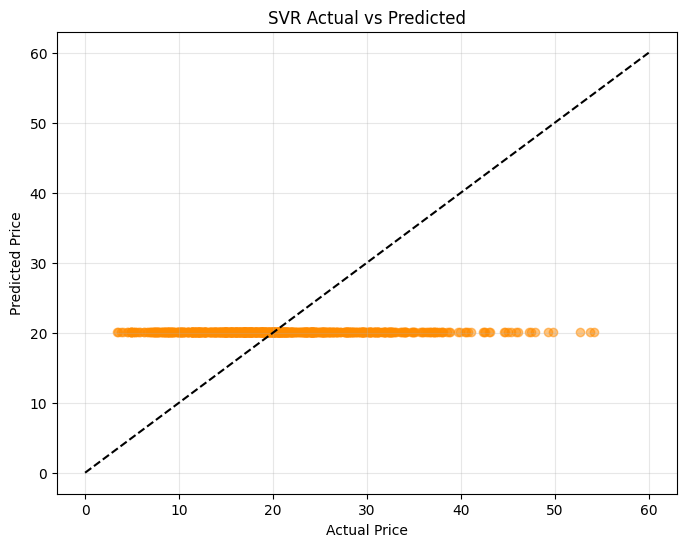

In [123]:
plt.figure(figsize=(8,6))

plt.scatter(
    test_target/1000000,
    rbf_pred/1000000,
    color='darkorange',
    alpha=0.5
)

plt.plot(
    [0,60],
    [0,60],
    'k--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "SVR Actual vs Predicted"
)

plt.grid(alpha=0.3)

plt.show()

In [124]:
def evaluate_model(name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return [
        name,
        round(mse,2),
        round(mae,2),
        round(rmse,2),
        round(r2,4)
    ]

In [125]:
results = []

# Ridge
results.append(
    evaluate_model(
        "Ridge",
        test_target,
        ridge_model_v2_pred
    )
)

# Lasso
results.append(
    evaluate_model(
        "Lasso",
        test_target,
        lasso_model_v2_pred
    )
)

# Decision Tree
results.append(
    evaluate_model(
        "Decision Tree",
        test_target,
        dt_pred
    )
)

# Random Forest
results.append(
    evaluate_model(
        "Random Forest",
        test_target,
        rf_pred
    )
)

# Linear SVR
results.append(
    evaluate_model(
        "Linear SVR",
        test_target,
        linear_pred
    )
)

# RBF SVR
results.append(
    evaluate_model(
        "RBF SVR",
        test_target,
        rbf_pred
    )
)

In [126]:
final_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MSE",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

print(final_results)

           Model           MSE         MAE        RMSE  R2 Score
0          Ridge  6.545413e+12  1959197.94  2558400.49    0.9187
1          Lasso  6.543997e+12  1959378.45  2558123.65    0.9187
2  Decision Tree  9.385836e+12  2325303.89  3063631.25    0.8835
3  Random Forest  5.929023e+12  1788361.00  2434958.59    0.9264
4     Linear SVR  1.455143e+13  2852164.71  3814633.47    0.8193
5        RBF SVR  8.077428e+13  6994139.17  8987451.47   -0.0030


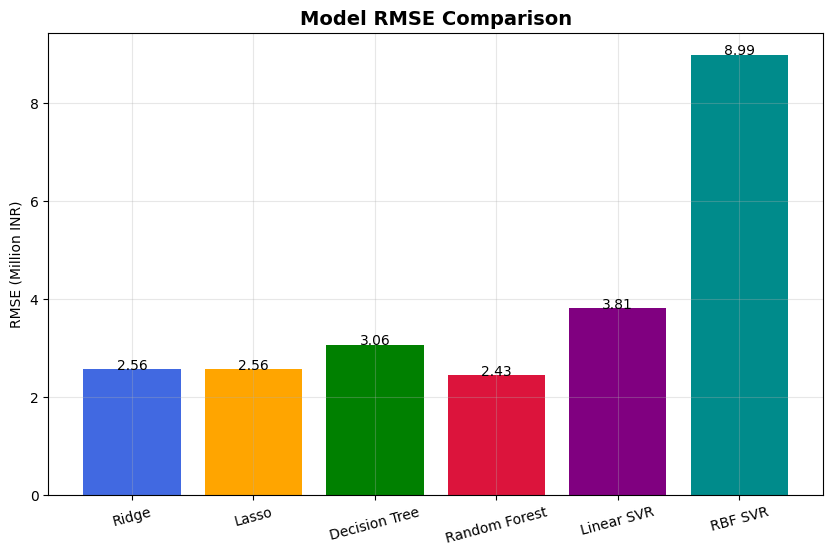

In [127]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results["Model"],
    final_results["RMSE"]/1000000,
    color=[
        'royalblue',
        'orange',
        'green',
        'crimson',
        'purple',
        'darkcyan'
    ]
)

plt.xticks(rotation=15)

plt.ylabel("RMSE (Million INR)")

plt.title(
    "Model RMSE Comparison",
    fontsize=14,
    fontweight='bold'
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center'
    )

plt.grid(alpha=0.3)

plt.show()

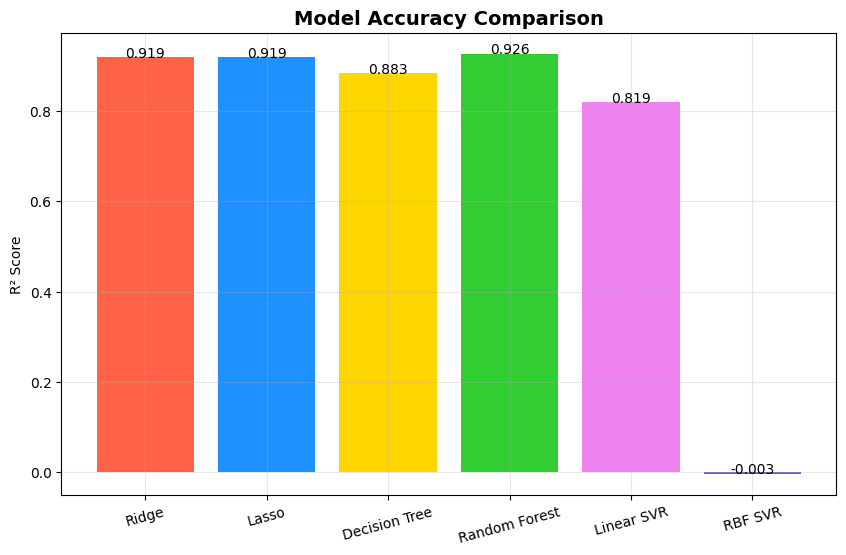

In [128]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results["Model"],
    final_results["R2 Score"],
    color=[
        'tomato',
        'dodgerblue',
        'gold',
        'limegreen',
        'violet',
        'slateblue'
    ]
)

plt.xticks(rotation=15)

plt.ylabel("R² Score")

plt.title(
    "Model Accuracy Comparison",
    fontsize=14,
    fontweight='bold'
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center'
    )

plt.grid(alpha=0.3)

plt.show()

In [129]:
best_model = final_results.sort_values(
    by="R2 Score",
    ascending=False
)

print(best_model)

           Model           MSE         MAE        RMSE  R2 Score
3  Random Forest  5.929023e+12  1788361.00  2434958.59    0.9264
0          Ridge  6.545413e+12  1959197.94  2558400.49    0.9187
1          Lasso  6.543997e+12  1959378.45  2558123.65    0.9187
2  Decision Tree  9.385836e+12  2325303.89  3063631.25    0.8835
4     Linear SVR  1.455143e+13  2852164.71  3814633.47    0.8193
5        RBF SVR  8.077428e+13  6994139.17  8987451.47   -0.0030


In [130]:
print("MODEL ANALYSIS\n")

print(
    "1. Ridge & Lasso:"
)

print(
    "- Reduce overfitting using regularization."
)

print(
    "- Stable and balanced models."
)

print("\n2. Decision Tree:")

print(
    "- Can easily overfit if tree depth is high."
)

print(
    "- Sensitive to noisy data."
)

print("\n3. Random Forest:")

print(
    "- Reduces overfitting using multiple trees."
)

print(
    "- Better generalization."
)

print("\n4. Linear SVR:")

print(
    "- Works well for linear patterns."
)

print(
    "- May underfit complex data."
)

print("\n5. RBF SVR:")

print(
    "- Handles non-linear relationships better."
)

print(
    "- Can overfit if gamma is too high."
)

MODEL ANALYSIS

1. Ridge & Lasso:
- Reduce overfitting using regularization.
- Stable and balanced models.

2. Decision Tree:
- Can easily overfit if tree depth is high.
- Sensitive to noisy data.

3. Random Forest:
- Reduces overfitting using multiple trees.
- Better generalization.

4. Linear SVR:
- Works well for linear patterns.
- May underfit complex data.

5. RBF SVR:
- Handles non-linear relationships better.
- Can overfit if gamma is too high.


In [131]:
print(
    "Random Forest and RBF SVR usually "
    "give better performance on complex "
    "real estate datasets."
)

print(
    "Ridge and Lasso help reduce "
    "overfitting using regularization."
)

Random Forest and RBF SVR usually give better performance on complex real estate datasets.
Ridge and Lasso help reduce overfitting using regularization.


In [132]:
print("="*60)
print("FINAL PROJECT REPORT")
print("="*60)

print("\n1. BEST PERFORMING MODEL")
print("-"*40)

print(
    "Random Forest Regression achieved "
    "the best overall performance with "
    "higher R² score and lower RMSE."
)

print(
    "The model handled complex and "
    "non-linear relationships effectively."
)

# ---------------------------------------------------

print("\n2. IMPACT OF REGULARIZATION")
print("-"*40)

print(
    "Ridge and Lasso Regression reduced "
    "overfitting by penalizing large coefficients."
)

print(
    "Lasso also performed feature selection "
    "by shrinking some coefficients to zero."
)

# ---------------------------------------------------

print("\n3. ROLE OF CROSS VALIDATION")
print("-"*40)

print(
    "Cross-validation improved model stability "
    "by evaluating models on multiple splits."
)

print(
    "It helped in selecting optimal "
    "hyperparameters and reduced bias."
)

# ---------------------------------------------------

print("\n4. LINEAR VS NON-LINEAR MODELS")
print("-"*40)

print(
    "Linear models are simple, fast, "
    "and interpretable."
)

print(
    "Non-linear models like Random Forest "
    "and SVR captured complex data patterns "
    "more effectively."
)

# ---------------------------------------------------

print("\n5. BUSINESS INTERPRETATION")
print("-"*40)

print(
    "Important features affecting house prices:"
)

print(
    "- Area Size"
)

print(
    "- Location Score"
)

print(
    "- Number of Bedrooms"
)

print(
    "- Property Age"
)

print(
    "The predictive system can help "
    "real estate companies estimate "
    "property prices more accurately."
)

# ---------------------------------------------------

print("\n6. OVERFITTING / UNDERFITTING")
print("-"*40)

print(
    "Decision Tree showed signs of overfitting "
    "when tree depth increased."
)

print(
    "Linear models slightly underfit "
    "complex relationships."
)

print(
    "Random Forest provided the best "
    "balance between bias and variance."
)

# ---------------------------------------------------

print("\n7. FINAL CONCLUSION")
print("-"*40)

print(
    "Random Forest and RBF SVR delivered "
    "the best predictive performance."
)

print(
    "Regularization and cross-validation "
    "improved model generalization."
)

print(
    "The project successfully compared "
    "linear, tree-based, and support "
    "vector regression models."
)

print("\nProject Completed Successfully ✅")

FINAL PROJECT REPORT

1. BEST PERFORMING MODEL
----------------------------------------
Random Forest Regression achieved the best overall performance with higher R² score and lower RMSE.
The model handled complex and non-linear relationships effectively.

2. IMPACT OF REGULARIZATION
----------------------------------------
Ridge and Lasso Regression reduced overfitting by penalizing large coefficients.
Lasso also performed feature selection by shrinking some coefficients to zero.

3. ROLE OF CROSS VALIDATION
----------------------------------------
Cross-validation improved model stability by evaluating models on multiple splits.
It helped in selecting optimal hyperparameters and reduced bias.

4. LINEAR VS NON-LINEAR MODELS
----------------------------------------
Linear models are simple, fast, and interpretable.
Non-linear models like Random Forest and SVR captured complex data patterns more effectively.

5. BUSINESS INTERPRETATION
----------------------------------------
Important